In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (12.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and direc

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Data_통합 (1).xlsx to Data_통합 (1).xlsx


In [ ]:
# 파일 경로
file_path = "Data_통합 (1).xlsx"

# 엑셀 파일에 있는 시트 이름 확인
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)  # ['Sheet1', 'Sheet2', ...]


['Sheet', 'EBITDA', '인건비', '유무형리스자산의증가', '매출원가', '수익']


In [ ]:
dfs = {}
for sheet in xls.sheet_names:
    print(f"Loading {sheet} ...")

    if sheet == "Sheet":
        # 첫 번째 행이 컬럼명
        dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)
    else:
        # 두 번째 행부터 컬럼명 (header=1)
        dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet, header=1)

    print(f"{sheet} shape: {dfs[sheet].shape}")

Loading Sheet ...
Sheet shape: (374340, 14)
Loading EBITDA ...
EBITDA shape: (7342, 112)
Loading 인건비 ...
인건비 shape: (7342, 112)
Loading 유무형리스자산의증가 ...
유무형리스자산의증가 shape: (7342, 112)
Loading 매출원가 ...
매출원가 shape: (7342, 112)
Loading 수익 ...
수익 shape: (7342, 112)


In [ ]:
dfs["Sheet"]

,업체코드,종목코드,종목명,691005.업체명,691020.사업자번호,691050.상장일,691060.결산월,691450.KSIC-세세분류(11차),DATE,EBITDA,인건비,"유,무형,리스자산의증가",매출원가,수익(매출액)
0,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-01-01,0.000000e+00,3829199.0,0.000000e+00,1.698668e+10,2.874157e+10
1,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-04-01,0.000000e+00,4129827.0,0.000000e+00,2.042499e+10,3.281942e+10
2,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-07-01,0.000000e+00,3811223.0,0.000000e+00,2.191622e+10,3.407650e+10
3,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-10-01,4.886518e+09,7843796.0,4.438878e+09,2.584407e+10,4.259254e+10
4,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2001-01-01,0.000000e+00,4329948.0,0.000000e+00,1.674465e+10,3.004641e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374335,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-04-01,-9.589924e+09,-2940319.0,9.632000e+06,0.000000e+00,0.000000e+00
374336,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-07-01,-1.188333e+10,7760477.0,5.462700e+07,0.000000e+00,1.090765e+09
374337,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-10-01,3.202594e+10,-7760477.0,-1.113170e+08,0.000000e+00,-1.090765e+09
374338,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2025-01-01,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00


In [ ]:
dfs["EBITDA"]

,업체코드,종목코드,종목명,691005.업체명,691020.사업자번호,691050.상장일,691060.결산월,691450.KSIC-세세분류(11차),2000/1Quarter\nS29700.EBITDA,2000/Semi Annual\nS29700.EBITDA,...,2023/3Quarter\nS29700.EBITDA,2023/Annual\nS29700.EBITDA,2024/1Quarter\nS29700.EBITDA,2024/Semi Annual\nS29700.EBITDA,2024/3Quarter\nS29700.EBITDA,2024/Annual\nS29700.EBITDA,2025/1Quarter\nS29700.EBITDA,2025/Semi Annual\nS29700.EBITDA,2025/3Quarter\nS29700.EBITDA,2025/Annual\nS29700.EBITDA
0,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,0,0,...,28094073000,29126513000,9428263000,18144959000,22849875000,30056892000,6301168000,10295999000,NaN,NaN
1,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,0,0,...,-4634247000,-6053070000,-1602558000,-2680685000,-3342275000,-5348786000,-743574000,-946959000,NaN,NaN
2,N320684,A000050,경방,(주)경방,107-81-05232,1956-03-03,12.0,G47119.기타 대형 종합 소매업,0,0,...,41446934000,63476049000,17667002000,23714930000,36109562000,57541459000,16575676000,24607740000,NaN,NaN
3,N320730,A000070,삼양홀딩스,(주)삼양홀딩스,208-81-01320,1968-12-27,12.0,K64992.지주회사,0,0,...,62534619000,72646143000,33618068000,52302827000,67174023000,78582444000,25333795000,44019087000,NaN,NaN
4,N310581,A000080,하이트진로,하이트진로(주),214-81-00777,2009-10-19,12.0,NaN,0,0,...,179310909000,244078286000,76294660000,176661594000,279134552000,343690249000,95104514000,190655024000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7337,NJB0688,A950170,JTC,(주)제이티씨,NaN,2018-04-06,2.0,G47130.면세점,0,0,...,6820133000,-23581936000,15494534000,11093324000,11454659000,-6333496000,0,0,NaN,NaN
7338,NJV2282,A950190,고스트스튜디오,고스트스튜디오(주),NaN,2020-08-18,12.0,J58212.모바일 게임 소프트웨어 개발 및 공급업,0,0,...,8446323000,4219032000,5733962000,5143098000,3973471000,-14850531000,0,0,NaN,NaN
7339,NLI6549,A950200,소마젠,(주)소마젠,NaN,2020-07-13,12.0,NaN,0,0,...,-44254000,-16038000,-676381000,251713000,183701000,240967000,0,0,NaN,NaN
7340,NMB1659,A950210,프레스티지바이오파마,프레스티지바이오파마,NaN,2021-02-05,6.0,M70113.의학 및 약학 연구개발업,0,0,...,4110136000,-2010435000,0,0,-22727948000,-1842269000,0,0,NaN,NaN


In [ ]:
dfs["Sheet"]['691450.KSIC-세세분류(11차)'].unique()

array(['C21212.합성의약품 및 기타 완제 의약품 제조업', 'C31921.모터사이클 제조업',
       'G47119.기타 대형 종합 소매업', 'K64992.지주회사', nan,
       'C20111.석유화학계 기초 화학물질 제조업', 'C30121.내연기관 승용차 및 기타 여객용 자동차 제조업',
       'C30399.그 외 자동차용 신품 부품 제조업', 'K65121.손해 보험업',
       'C20411.일반용 도료 및 관련제품 제조업', 'G46712.액체연료 및 관련제품 도매업',
       'C23211.정형 내화 요업제품 제조업', 'C29210.농업 및 임업용 기계 제조업',
       'K64209.기타 금융 투자업', 'C28302.기타 절연선 및 케이블 제조업', 'H49220.시외버스 운송업',
       'G46800.상품 종합 도매업', 'G46731.염료, 안료 및 관련제품 도매업',
       'C29223.금속 절삭기계 제조업', 'C20494.화약 및 불꽃제품 제조업',
       'C11129.기타 증류주 및 합성주 제조업', 'C28123.배전반 및 전기 자동제어반 제조업',
       'C23311.시멘트 제조업', 'C13101.면 방적업', 'C24131.주철관 제조업',
       'C26112.비메모리용 및 기타 전자집적회로 제조업', 'L68112.비주거용 건물 임대업',
       'C17102.신문용지 제조업', 'C13211.면직물 직조업', 'C24123.철강선 제조업',
       'C27199.그 외 기타 의료용 기기 제조업', 'G46109.상품 종합 중개업', 'C10512.곡물 제분업',
       'K66121.증권 중개업', 'C28410.전구 및 램프 제조업', 'C20129.기타 기초 무기 화학물질 제조업',
       'C20119.기타 기초 유기화학 물질 제조업', 'C24112.제강업', 'C14120.속옷 및 잠옷 제조업',
     

In [ ]:
arr = dfs["Sheet"]['691450.KSIC-세세분류(11차)'].unique()
arr2 = pd.DataFrame(arr, columns=['산업분류'])
arr2

,산업분류
0,C21212.합성의약품 및 기타 완제 의약품 제조업
1,C31921.모터사이클 제조업
2,G47119.기타 대형 종합 소매업
3,K64992.지주회사
4,NaN
...,...
473,C29222.디지털 적층 성형기계 제조업
474,C15219.기타 신발 제조업
475,C29163.컨베이어장치 제조업
476,G45212.자동차용 전용 신품 부품 판매업


In [ ]:
arr2.to_csv('기업데이터 산업.csv', encoding='utf-8-sig')
files.download('기업데이터 산업.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 산업구분.csv to 산업구분.csv


In [ ]:
df1 = pd.read_csv('산업구분.csv')
df1

,산업 구분,산업코드
0,농림어업,A
1,광업,B
2,음식료품 제조업_식료품,C10
3,음식료품 제조업_음료,C11
4,음식료품 제조업_담배,C12
5,섬유 및 가죽제품 제조업_섬유,C13
6,섬유 및 가죽제품 제조업_의복모피,C14
7,섬유 및 가죽제품 제조업_가죽가방신발,C15
8,"목재, 종이, 인쇄 및 복제업_목재나무",C16
9,"목재, 종이, 인쇄 및 복제업_펄프종이",C17


In [ ]:
def match_industry(row, code_dict):
    if pd.isna(row):
        return np.nan
    for code, industry in code_dict.items():
        if str(row).startswith(code):
            return industry
    return ''

code_dict = dict(zip(df1['산업코드'], df1['산업 구분']))


In [ ]:
# df2['산업분류']에서 코드 부분만 추출해서 매핑
arr2['매핑한 산업'] = arr2['산업분류'].apply(lambda x: match_industry(x, code_dict))
arr2

,산업분류,매핑한 산업
0,C21212.합성의약품 및 기타 완제 의약품 제조업,화학물질 및 화학제품 제조업_의료물질의약품
1,C31921.모터사이클 제조업,운송장비 제조업_조선기타운수
2,G47119.기타 대형 종합 소매업,도소매업
3,K64992.지주회사,금융 및 보험업
4,NaN,NaN
...,...,...
473,C29222.디지털 적층 성형기계 제조업,기계 및 장비 제조업
474,C15219.기타 신발 제조업,섬유 및 가죽제품 제조업_가죽가방신발
475,C29163.컨베이어장치 제조업,기계 및 장비 제조업
476,G45212.자동차용 전용 신품 부품 판매업,도소매업


In [ ]:
dfs["Sheet"]['매핑한 산업'] = dfs["Sheet"]['691450.KSIC-세세분류(11차)'].apply(lambda x: match_industry(x, code_dict))
dfs["Sheet"]

,업체코드,종목코드,종목명,691005.업체명,691020.사업자번호,691050.상장일,691060.결산월,691450.KSIC-세세분류(11차),DATE,EBITDA,인건비,"유,무형,리스자산의증가",매출원가,수익(매출액),매핑한 산업
0,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-01-01,0.000000e+00,3829199.0,0.000000e+00,1.698668e+10,2.874157e+10,화학물질 및 화학제품 제조업_의료물질의약품
1,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-04-01,0.000000e+00,4129827.0,0.000000e+00,2.042499e+10,3.281942e+10,화학물질 및 화학제품 제조업_의료물질의약품
2,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-07-01,0.000000e+00,3811223.0,0.000000e+00,2.191622e+10,3.407650e+10,화학물질 및 화학제품 제조업_의료물질의약품
3,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2000-10-01,4.886518e+09,7843796.0,4.438878e+09,2.584407e+10,4.259254e+10,화학물질 및 화학제품 제조업_의료물질의약품
4,N350605,A000020,동화약품,동화약품(주),110-81-00102,1976-03-24,12.0,C21212.합성의약품 및 기타 완제 의약품 제조업,2001-01-01,0.000000e+00,4329948.0,0.000000e+00,1.674465e+10,3.004641e+10,화학물질 및 화학제품 제조업_의료물질의약품
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374335,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-04-01,-9.589924e+09,-2940319.0,9.632000e+06,0.000000e+00,0.000000e+00,"전문, 과학 및 기술관련 서비스업"
374336,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-07-01,-1.188333e+10,7760477.0,5.462700e+07,0.000000e+00,1.090765e+09,"전문, 과학 및 기술관련 서비스업"
374337,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2024-10-01,3.202594e+10,-7760477.0,-1.113170e+08,0.000000e+00,-1.090765e+09,"전문, 과학 및 기술관련 서비스업"
374338,NMC8807,A950220,네오이뮨텍,(주)네오이뮨텍,NaN,2021-03-16,12.0,M70130.자연과학 및 공학 융합 연구개발업,2025-01-01,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,"전문, 과학 및 기술관련 서비스업"


In [ ]:
industry_list = [
   "전기장비 제조업","기계 및 장비 제조업","운송장비 제조업_자동차", "운송장비 제조업_조선기타운수", "기타 제조업 및 산업용 장비 수리업_가구","기타 제조업 및 산업용 장비 수리업_기타제품","전기업 + 가스, 증기 및 공기조절 공급업",
   "수도, 하수 및 폐기물 처리, 원료 재생업","건물건설 및 건축보수업","토목건설업","도소매업","숙박 및 음식점업","운수업"
]

filtered_df = dfs["Sheet"][dfs["Sheet"]['매핑한 산업'].isin(industry_list)]
filtered_df

,업체코드,종목코드,종목명,691005.업체명,691020.사업자번호,691050.상장일,691060.결산월,691450.KSIC-세세분류(11차),DATE,EBITDA,인건비,"유,무형,리스자산의증가",매출원가,수익(매출액),매핑한 산업
102,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-01-01,0.000000e+00,544152.0,0.000000e+00,2.799049e+10,3.131630e+10,운송장비 제조업_조선기타운수
103,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-04-01,0.000000e+00,529446.0,0.000000e+00,3.218369e+10,3.792470e+10,운송장비 제조업_조선기타운수
104,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-07-01,0.000000e+00,530405.0,0.000000e+00,3.185522e+10,3.875848e+10,운송장비 제조업_조선기타운수
105,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-10-01,-7.798581e+09,10143695.0,3.741770e+09,2.611673e+10,2.787019e+10,운송장비 제조업_조선기타운수
106,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2001-01-01,0.000000e+00,537856.0,0.000000e+00,2.133264e+10,2.561618e+10,운송장비 제조업_조선기타운수
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373927,NJB0688,A950170,JTC,(주)제이티씨,NaN,2018-04-06,2.0,G47130.면세점,2024-04-01,1.109332e+10,5284616.0,3.226334e+09,1.960907e+10,7.749555e+10,도소매업
373928,NJB0688,A950170,JTC,(주)제이티씨,NaN,2018-04-06,2.0,G47130.면세점,2024-07-01,1.145466e+10,5532262.0,1.890192e+09,1.798675e+10,7.447296e+10,도소매업
373929,NJB0688,A950170,JTC,(주)제이티씨,NaN,2018-04-06,2.0,G47130.면세점,2024-10-01,-6.333496e+09,-3883023.0,-4.152853e+09,-2.321521e+10,-8.668787e+10,도소매업
373930,NJB0688,A950170,JTC,(주)제이티씨,NaN,2018-04-06,2.0,G47130.면세점,2025-01-01,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,도소매업


In [ ]:
filtered_df.columns

Index(['업체코드', '종목코드', '종목명', '691005.업체명', '691020.사업자번호', '691050.상장일',
       '691060.결산월', '691450.KSIC-세세분류(11차)', 'DATE', 'EBITDA', '인건비',
       '유,무형,리스자산의증가', '매출원가', '수익(매출액)', '매핑한 산업'],
      dtype='object')

In [ ]:
filtered_df = filtered_df.rename(columns={'691005.업체명':'업체명', '691020.사업자번호':'사업자번호',
                                    '691050.상장일':'상장번호', '691050.상장일':'상장일',
                                    '691060.결산월':'결산월', '691450.KSIC-세세분류(11차)':'산업세세분류',
                                    'DATE':'조사일'})
filtered_df.head()

,업체코드,종목코드,종목명,업체명,사업자번호,상장일,결산월,산업세세분류,조사일,EBITDA,인건비,"유,무형,리스자산의증가",매출원가,수익(매출액),매핑한 산업
102,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-01-01,0.000000e+00,544152.0,0.000000e+00,2.799049e+10,3.131630e+10,운송장비 제조업_조선기타운수
103,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-04-01,0.000000e+00,529446.0,0.000000e+00,3.218369e+10,3.792470e+10,운송장비 제조업_조선기타운수
104,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-07-01,0.000000e+00,530405.0,0.000000e+00,3.185522e+10,3.875848e+10,운송장비 제조업_조선기타운수
105,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2000-10-01,-7.798581e+09,10143695.0,3.741770e+09,2.611673e+10,2.787019e+10,운송장비 제조업_조선기타운수
106,N320498,A000040,KR모터스,KR모터스(주),305-81-00020,1976-05-25,12.0,C31921.모터사이클 제조업,2001-01-01,0.000000e+00,537856.0,0.000000e+00,2.133264e+10,2.561618e+10,운송장비 제조업_조선기타운수


In [ ]:
filtered_df['매핑한 산업'].value_counts()

,count
매핑한 산업,
기계 및 장비 제조업,22644
도소매업,17238
운송장비 제조업_자동차,10914
전기장비 제조업,8874
운송장비 제조업_조선기타운수,2448
운수업,2448
토목건설업,1734
기타 제조업 및 산업용 장비 수리업_기타제품,1428
건물건설 및 건축보수업,1020


In [ ]:
filtered_df.columns

Index(['업체코드', '종목코드', '종목명', '업체명', '사업자번호', '상장일', '결산월', '산업세세분류', '조사일',
       'EBITDA', '인건비', '유,무형,리스자산의증가', '매출원가', '수익(매출액)', '매핑한 산업'],
      dtype='object')

In [ ]:
columns_of_interest = ['EBITDA', '인건비', '유,무형,리스자산의증가', '매출원가', '수익(매출액)']

grouped_stats = filtered_df.groupby('매핑한 산업')[columns_of_interest].agg(['mean', 'median', 'var'])
grouped_stats

EBITDA                              \
                                  mean        median           var   
매핑한 산업                                                               
건물건설 및 건축보수업              1.381368e+10  1.806123e+09  3.569174e+21   
기계 및 장비 제조업               2.772169e+09  0.000000e+00  1.567695e+20   
기타 제조업 및 산업용 장비 수리업_가구    3.530952e+09  1.027242e+09  3.885054e+19   
기타 제조업 및 산업용 장비 수리업_기타제품  6.835440e+08  0.000000e+00  7.521552e+18   
도소매업                      9.006147e+09  1.856185e+08  1.480776e+21   
수도, 하수 및 폐기물 처리, 원료 재생업   2.902022e+09  1.908069e+09  1.525418e+19   
숙박 및 음식점업                 5.038072e+09  1.288684e+09  6.747827e+19   
운송장비 제조업_자동차              2.469359e+10  1.273926e+09  2.750787e+22   
운송장비 제조업_조선기타운수           1.019343e+10  0.000000e+00  5.241351e+21   
운수업                       5.416296e+10  3.243690e+09  3.925466e+22   
전기업 + 가스, 증기 및 공기조절 공급업   1.026308e+11  5.442078e+09  5.570881e+23   
전기장비 제조업                  4.425620e+09  0.000000e+00  3.753614e+21   
토목건설업                     4.387227e+09  1.298302e+09  1.351781e+20   

                                   인건비                           유,무형,리스자산의증가  \
                                  mean     median           var          mean   
매핑한 산업                                                                          
건물건설 및 건축보수업              1.459780e+07  1733151.5  4.505861e+15  2.013432e+09   
기계 및 장비 제조업               2.295446e+06   370370.0  1.754621e+14  1.517328e+09   
기타 제조업 및 산업용 장비 수리업_가구    2.651335e+06  1474136.5  1.523772e+13  1.814572e+09   
기타 제조업 및 산업용 장비 수리업_기타제품  8.658040e+05        0.0  7.373903e+12  5.824421e+08   
도소매업                      6.595572e+06   730235.5  1.082018e+15  4.675909e+09   
수도, 하수 및 폐기물 처리, 원료 재생업   1.085950e+06   581184.5  3.260259e+12  2.146831e+09   
숙박 및 음식점업                 5.431931e+06  1098056.5  4.665424e+14  5.193233e+09   
운송장비 제조업_자동차              1.125588e+07   800327.0  3.931874e+15  1.436769e+10   
운송장비 제조업_조선기타운수           8.724216e+06   363998.0  2.402104e+15  7.982153e+09   
운수업                       1.948021e+07  1701642.0  1.577042e+16  2.600813e+10   
전기업 + 가스, 증기 및 공기조절 공급업   2.389782e+07  6184527.0  4.386356e+15  1.729371e+11   
전기장비 제조업                  3.692078e+06   514495.0  5.306794e+14  4.522968e+09   
토목건설업                     8.603145e+06   856204.0  1.384013e+15  1.693260e+09   

                                                              매출원가  \
                                median           var          mean   
매핑한 산업                                                               
건물건설 및 건축보수업              5.956900e+07  5.097806e+19  2.489627e+11   
기계 및 장비 제조업               1.275200e+07  3.529937e+19  2.566572e+10   
기타 제조업 및 산업용 장비 수리업_가구    3.633420e+08  1.876132e+19  3.713823e+10   
기타 제조업 및 산업용 장비 수리업_기타제품  0.000000e+00  8.147931e+18  5.312799e+09   
도소매업                      5.555400e+07  7.064008e+20  1.454052e+11   
수도, 하수 및 폐기물 처리, 원료 재생업   5.575725e+08  1.306188e+19  1.113422e+10   
숙박 및 음식점업                 1.255550e+09  1.106886e+20  4.315918e+10   
운송장비 제조업_자동차              7.957970e+08  9.217125e+21  2.187340e+11   
운송장비 제조업_조선기타운수           9.207100e+07  6.907346e+20  1.924381e+11   
운수업                       1.356565e+09  6.906552e+21  3.704953e+11   
전기업 + 가스, 증기 및 공기조절 공급업   6.717264e+09  2.498081e+23  1.895224e+12   
전기장비 제조업                  8.651300e+07  8.261888e+20  5.913585e+10   
토목건설업                     1.817700e+08  2.515286e+19  3.896486e+10   

                                                           수익(매출액)  \
                                median           var          mean   
매핑한 산업                                                               
건물건설 및 건축보수업              5.983197e+10  2.900127e+23  2.756351e+11   
기계 및 장비 제조업               3.764896e+09  9.591760e+21  3.131624e+10   
기타 제조업 및 산업용 장비 수리업_가구    2.089729e+10  3.644246e+21  4.912366e+10   
기타 제조업 및 산업용 장비 수리업_기타제품  8.462625e+08  8.468628e+19  8.247727e+09   
도소매

In [ ]:
# 계층형 컬럼명을 언더바(_)로 연결해서 평면화
grouped_stats.columns = ['_'.join(col) for col in grouped_stats.columns]

grouped_stats = grouped_stats.reset_index()
grouped_stats

,매핑한 산업,EBITDA_mean,EBITDA_median,EBITDA_var,인건비_mean,인건비_median,인건비_var,"유,무형,리스자산의증가_mean","유,무형,리스자산의증가_median","유,무형,리스자산의증가_var",매출원가_mean,매출원가_median,매출원가_var,수익(매출액)_mean,수익(매출액)_median,수익(매출액)_var
0,건물건설 및 건축보수업,1.381368e+10,1.806123e+09,3.569174e+21,1.459780e+07,1733151.5,4.505861e+15,2.013432e+09,5.956900e+07,5.097806e+19,2.489627e+11,5.983197e+10,2.900127e+23,2.756351e+11,6.733335e+10,3.407485e+23
1,기계 및 장비 제조업,2.772169e+09,0.000000e+00,1.567695e+20,2.295446e+06,370370.0,1.754621e+14,1.517328e+09,1.275200e+07,3.529937e+19,2.566572e+10,3.764896e+09,9.591760e+21,3.131624e+10,5.114688e+09,1.334062e+22
2,기타 제조업 및 산업용 장비 수리업_가구,3.530952e+09,1.027242e+09,3.885054e+19,2.651335e+06,1474136.5,1.523772e+13,1.814572e+09,3.633420e+08,1.876132e+19,3.713823e+10,2.089729e+10,3.644246e+21,4.912366e+10,3.109316e+10,5.230689e+21
3,기타 제조업 및 산업용 장비 수리업_기타제품,6.835440e+08,0.000000e+00,7.521552e+18,8.658040e+05,0.0,7.373903e+12,5.824421e+08,0.000000e+00,8.147931e+18,5.312799e+09,8.462625e+08,8.468628e+19,8.247727e+09,1.535383e+09,2.121215e+20
4,도소매업,9.006147e+09,1.856185e+08,1.480776e+21,6.595572e+06,730235.5,1.082018e+15,4.675909e+09,5.555400e+07,7.064008e+20,1.454052e+11,7.890628e+09,3.889983e+23,1.754187e+11,1.068349e+10,4.874421e+23
5,"수도, 하수 및 폐기물 처리, 원료 재생업",2.902022e+09,1.908069e+09,1.525418e+19,1.085950e+06,581184.5,3.260259e+12,2.146831e+09,5.575725e+08,1.306188e+19,1.113422e+10,9.781482e+09,1.306524e+20,1.492725e+10,1.316337e+10,1.739775e+20
6,숙박 및 음식점업,5.038072e+09,1.288684e+09,6.747827e+19,5.431931e+06,1098056.5,4.665424e+14,5.193233e+09,1.255550e+09,1.106886e+20,4.315918e+10,9.506830e+09,6.096108e+21,5.268897e+10,1.596226e+10,8.188350e+21
7,운송장비 제조업_자동차,2.469359e+10,1.273926e+09,2.750787e+22,1.125588e+07,800327.0,3.931874e+15,1.436769e+10,7.957970e+08,9.217125e+21,2.187340e+11,2.202358e+10,1.246428e+24,2.659278e+11,2.519735e+10,1.967227e+24
8,운송장비 제조업_조선기타운수,1.019343e+10,0.000000e+00,5.241351e+21,8.724216e+06,363998.0,2.402104e+15,7.982153e+09,9.207100e+07,6.907346e+20,1.924381e+11,4.799732e+09,2.834551e+23,2.094742e+11,6.135002e+09,3.338700e+23
9,운수업,5.416296e+10,3.243690e+09,3.925466e+22,1.948021e+07,1701642.0,1.577042e+16,2.600813e+10,1.356565e+09,6.906552e+21,3.704953e+11,7.644725e+10,5.535285e+23,4.228378e+11,7.947674e+10,7.435406e+23


In [ ]:
grouped_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   매핑한 산업               13 non-null     object 
 1   EBITDA_mean          13 non-null     float64
 2   EBITDA_median        13 non-null     float64
 3   EBITDA_var           13 non-null     float64
 4   인건비_mean             13 non-null     float64
 5   인건비_median           13 non-null     float64
 6   인건비_var              13 non-null     float64
 7   유,무형,리스자산의증가_mean    13 non-null     float64
 8   유,무형,리스자산의증가_median  13 non-null     float64
 9   유,무형,리스자산의증가_var     13 non-null     float64
 10  매출원가_mean            13 non-null     float64
 11  매출원가_median          13 non-null     float64
 12  매출원가_var             13 non-null     float64
 13  수익(매출액)_mean         13 non-null     float64
 14  수익(매출액)_median       13 non-null     float64
 15  수익(매출액)_var          13 non-null     float

In [ ]:
grouped_stats_mean = grouped_stats[['매핑한 산업', 'EBITDA_mean', '인건비_mean', '유,무형,리스자산의증가_mean', '매출원가_mean', '수익(매출액)_mean']]
grouped_stats_mean

,매핑한 산업,EBITDA_mean,인건비_mean,"유,무형,리스자산의증가_mean",매출원가_mean,수익(매출액)_mean
0,건물건설 및 건축보수업,1.381368e+10,1.459780e+07,2.013432e+09,2.489627e+11,2.756351e+11
1,기계 및 장비 제조업,2.772169e+09,2.295446e+06,1.517328e+09,2.566572e+10,3.131624e+10
2,기타 제조업 및 산업용 장비 수리업_가구,3.530952e+09,2.651335e+06,1.814572e+09,3.713823e+10,4.912366e+10
3,기타 제조업 및 산업용 장비 수리업_기타제품,6.835440e+08,8.658040e+05,5.824421e+08,5.312799e+09,8.247727e+09
4,도소매업,9.006147e+09,6.595572e+06,4.675909e+09,1.454052e+11,1.754187e+11
5,"수도, 하수 및 폐기물 처리, 원료 재생업",2.902022e+09,1.085950e+06,2.146831e+09,1.113422e+10,1.492725e+10
6,숙박 및 음식점업,5.038072e+09,5.431931e+06,5.193233e+09,4.315918e+10,5.268897e+10
7,운송장비 제조업_자동차,2.469359e+10,1.125588e+07,1.436769e+10,2.187340e+11,2.659278e+11
8,운송장비 제조업_조선기타운수,1.019343e+10,8.724216e+06,7.982153e+09,1.924381e+11,2.094742e+11
9,운수업,5.416296e+10,1.948021e+07,2.600813e+10,3.704953e+11,4.228378e+11


In [ ]:
# 최댓값을 가진 인덱스(행) 구하기
max_idx = grouped_stats_mean[['EBITDA_mean', '인건비_mean', '유,무형,리스자산의증가_mean', '매출원가_mean', '수익(매출액)_mean']].idxmax()

# 각 열별 최댓값과 해당 '매핑한 산업' 구하기
for col in ['EBITDA_mean', '인건비_mean', '유,무형,리스자산의증가_mean', '매출원가_mean', '수익(매출액)_mean']:
    idx = max_idx[col]
    industry = grouped_stats_mean.loc[idx, '매핑한 산업']
    max_value = grouped_stats_mean.loc[idx, col]
    print(f"{col} 최댓값: {max_value} (산업: {industry})")

EBITDA_mean 최댓값: 102630787437.2549 (산업: 전기업 + 가스, 증기 및 공기조절 공급업)
인건비_mean 최댓값: 23897815.170588236 (산업: 전기업 + 가스, 증기 및 공기조절 공급업)
유,무형,리스자산의증가_mean 최댓값: 172937059227.451 (산업: 전기업 + 가스, 증기 및 공기조절 공급업)
매출원가_mean 최댓값: 1895223836326.4707 (산업: 전기업 + 가스, 증기 및 공기조절 공급업)
수익(매출액)_mean 최댓값: 1954034898632.353 (산업: 전기업 + 가스, 증기 및 공기조절 공급업)


In [ ]:
corr = grouped_stats_mean.drop(columns='매핑한 산업').corr()
corr


,EBITDA_mean,인건비_mean,"유,무형,리스자산의증가_mean",매출원가_mean,수익(매출액)_mean
EBITDA_mean,1.000000,0.886776,0.931064,0.945675,0.951896
인건비_mean,0.886776,1.000000,0.725442,0.788972,0.800985
"유,무형,리스자산의증가_mean",0.931064,0.725442,1.000000,0.991143,0.989036
매출원가_mean,0.945675,0.788972,0.991143,1.000000,0.999660
수익(매출액)_mean,0.951896,0.800985,0.989036,0.999660,1.000000


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

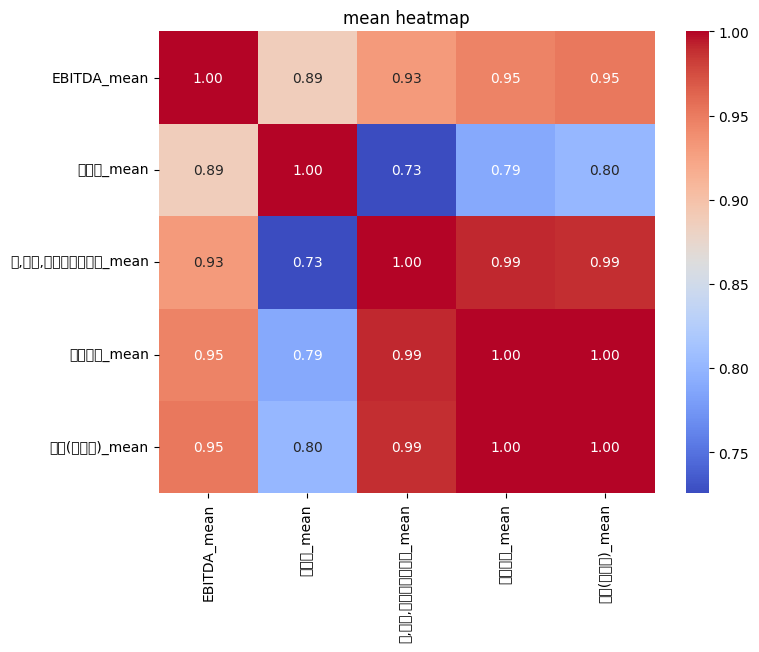

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('mean heatmap')
plt.show()

In [ ]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71502 entries, 102 to 373931
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   업체코드          71502 non-null  object        
 1   종목코드          71502 non-null  object        
 2   종목명           71502 non-null  object        
 3   업체명           71502 non-null  object        
 4   사업자번호         71298 non-null  object        
 5   상장일           71502 non-null  datetime64[ns]
 6   결산월           71502 non-null  float64       
 7   산업세세분류        71502 non-null  object        
 8   조사일           71502 non-null  datetime64[ns]
 9   EBITDA        71502 non-null  float64       
 10  인건비           71502 non-null  float64       
 11  유,무형,리스자산의증가  71502 non-null  float64       
 12  매출원가          71502 non-null  float64       
 13  수익(매출액)       71502 non-null  float64       
 14  매핑한 산업        71502 non-null  object        
dtypes: datetime64[ns](2), float64(6), obje

In [ ]:
# 반복문으로 한 번에
columns = ['EBITDA', '인건비', '유,무형,리스자산의증가', '매출원가', '수익(매출액)']

for industry in filtered_df['매핑한 산업'].unique():
    industry_df = filtered_df[filtered_df['매핑한 산업'] == industry]
    corr_matrix = industry_df[columns].corr()
    print(f"산업: {industry}")
    print(corr_matrix)
    print("\n" + "="*40 + "\n")


산업: 운송장비 제조업_조선기타운수
                EBITDA       인건비  유,무형,리스자산의증가      매출원가   수익(매출액)
EBITDA        1.000000  0.112978      0.413258  0.367335  0.468001
인건비           0.112978  1.000000      0.339154  0.298261  0.289747
유,무형,리스자산의증가  0.413258  0.339154      1.000000  0.706228  0.713861
매출원가          0.367335  0.298261      0.706228  1.000000  0.993026
수익(매출액)       0.468001  0.289747      0.713861  0.993026  1.000000


산업: 도소매업
                EBITDA       인건비  유,무형,리스자산의증가      매출원가   수익(매출액)
EBITDA        1.000000  0.698780      0.788026  0.587082  0.676843
인건비           0.698780  1.000000      0.552424  0.480620  0.565751
유,무형,리스자산의증가  0.788026  0.552424      1.000000  0.391518  0.473115
매출원가          0.587082  0.480620      0.391518  1.000000  0.990321
수익(매출액)       0.676843  0.565751      0.473115  0.990321  1.000000


산업: 운송장비 제조업_자동차
                EBITDA       인건비  유,무형,리스자산의증가      매출원가   수익(매출액)
EBITDA        1.000000  0.742925      0.829485  0.889105  0.905573
인건비         

In [ ]:
columns = ['EBITDA', '인건비', '유,무형,리스자산의증가', '매출원가', '수익(매출액)']

for industry in filtered_df['매핑한 산업'].unique():
    # 해당 산업 데이터 필터링
    industry_df = filtered_df[filtered_df['매핑한 산업'] == industry]

    # 조사일 기준 그룹바이 후 합산
    grouped = industry_df.groupby('조사일')[columns].sum()

    # 1x5 subplot 생성
    fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True)
    fig.suptitle(f'industry: {industry} - each sum trend')

    # 각 변수별 시계열 그리기
    for i, col in enumerate(columns):
        axes[i].plot(grouped.index, grouped[col], marker='o')
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
filtered_df.to_csv('임지오.csv', encoding='utf-8-sig')
files.download('임지오.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>